<a href="https://colab.research.google.com/github/suhaasteja/GenAI_notebooks/blob/main/text_to_meme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Autonomous Multimodal RAG Meme Generator

Welcome! This notebook demonstrates how to build a fully autonomous, context-aware image generation pipeline.

Traditional automated image generation relies on hardcoded spatial coordinates (e.g., stamping text at `y=20`). This approach breaks instantly if an image's focal point (like a face) happens to be at the top of the frame. This notebook solves that problem by integrating retrieval architecture with advanced computer vision to "understand" both the semantic meaning and the physical layout of an image.

### 🏗️ The Architecture:
1. **Multimodal Context Retrieval (Gemini):** We use Google's `gemini-embedding-2-preview` to map raw text prompts and unstructured image templates into a shared vector space. A simple Cosine Similarity search mathematically pairs your text intent with the correct visual template.
2. **Zero-Shot Segmentation (Meta's SAM):** Meta's Segment Anything Model (`sam_vit_b`) scans the chosen image to autonomously map subjects and create bounding masks, without requiring any manual point-prompting.
3. **Spatial Density Heuristics:** We calculate a "subject density map" from SAM's output to determine optimal text "safe zones." The script dynamically routes text placement (top vs. bottom) to guarantee it never covers the focal subjects.

### 🚀 Getting Started
* **API Key:** Ensure your Gemini API Key is loaded in Colab's Secrets tab (the key icon on the left sidebar) as `GEMINI_API_KEY`.
* **Hardware:** Ensure your runtime is set to use a GPU (`Runtime` > `Change runtime type` > `T4 GPU`) so the SAM vision model can run efficiently.

In [4]:
!pip install google-genai numpy pillow requests


User Query: 'One does not simply hardcode spatial coordinates'

--- Similarity Scores ---
distracted_boyfriend: 0.2947
this_is_fine: 0.3192
one_does_not_simply: 0.3359

✅ Best match: one_does_not_simply!


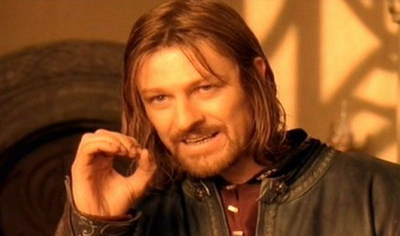

In [16]:
import os
import numpy as np
import requests
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO
from IPython.display import display
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# 1. Initialize the client
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY # Replace with your key
client = genai.Client()

# 2. Setup a dummy "database" of meme templates
meme_urls = {
    "distracted_boyfriend": "https://i.imgflip.com/1ur9b0.jpg",
    "this_is_fine": "https://i.imgflip.com/1jwhww.jpg",
    "one_does_not_simply": "https://i.imgflip.com/1bij.jpg" # <-- Your new image!
}

def get_image_bytes(url):
    return requests.get(url).content

print("Downloading and embedding meme templates...")
image_embeddings = {}

# 3. Embed the images using Gemini Embedding 2
for name, url in meme_urls.items():
    img_bytes = get_image_bytes(url)
    result = client.models.embed_content(
        model="gemini-embedding-2-preview",
        contents=[
            types.Part.from_bytes(data=img_bytes, mime_type="image/jpeg")
        ]
    )
    # Extract the vector representation
    image_embeddings[name] = {
        "vector": np.array(result.embeddings[0].values),
        "bytes": img_bytes
    }

# 4. Embed the user's text query
user_query = "One does not simply hardcode spatial coordinates"
print(f"\nUser Query: '{user_query}'")

text_result = client.models.embed_content(
    model="gemini-embedding-2-preview",
    contents=user_query
)
text_vector = np.array(text_result.embeddings[0].values)

# 5. Calculate Cosine Similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

best_match_name = None
highest_score = -1

print("\n--- Similarity Scores ---")
for name, data in image_embeddings.items():
    score = cosine_similarity(text_vector, data["vector"])
    print(f"{name}: {score:.4f}")

    if score > highest_score:
        highest_score = score
        best_match_name = name

print(f"\n✅ Best match: {best_match_name}!")

# Display the winning meme
best_image = Image.open(BytesIO(image_embeddings[best_match_name]["bytes"]))
best_image.thumbnail((400, 400))
display(best_image)

Generating final meme for: one_does_not_simply...



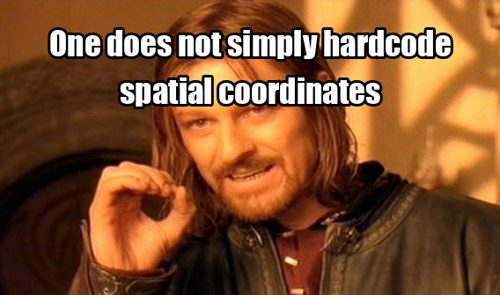

In [17]:
from PIL import ImageDraw, ImageFont
import textwrap
import urllib.request
from io import BytesIO

# 1. Download the classic "Impact" font to Colab using a new, working source
font_url = "https://raw.githubusercontent.com/sophilabs/macgifer/master/static/font/impact.ttf"
urllib.request.urlretrieve(font_url, "impact.ttf")

def overlay_text_on_meme(image_bytes, text):
    # Open image from bytes
    img = Image.open(BytesIO(image_bytes)).convert("RGBA")
    draw = ImageDraw.Draw(img)

    # Calculate a dynamic font size based on the image width
    font_size = max(20, int(img.width / 15))
    font = ImageFont.truetype("impact.ttf", font_size)

    # Wrap text so it doesn't run off the edges
    chars_per_line = int(img.width / (font_size * 0.45))
    wrapped_text = textwrap.fill(text, width=chars_per_line)

    # Get text dimensions to perfectly center it
    bbox = draw.multiline_textbbox((0, 0), wrapped_text, font=font, align="center")
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    # Position: Centered near the top margin
    x = (img.width - text_w) / 2
    y = 20

    # Draw the text with a black stroke/outline (classic meme style)
    draw.multiline_text(
        (x, y),
        wrapped_text,
        font=font,
        fill="white",
        align="center",
        stroke_width=3,
        stroke_fill="black"
    )

    # Convert back to RGB to display nicely in Colab
    return img.convert("RGB")

# --- Run the updated rendering ---

# Use the best match from the previous cell
winning_image_bytes = image_embeddings[best_match_name]["bytes"]

print(f"Generating final meme for: {best_match_name}...\n")

# Pass the bytes and the user's original query to our new function
final_meme = overlay_text_on_meme(winning_image_bytes, user_query)

# Display the finished product!
final_meme.thumbnail((500, 500))
display(final_meme)

In [7]:
!pip install torch torchvision opencv-python
!pip install git+https://github.com/facebookresearch/segment-anything.git
!wget -nc https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-acj5p141
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-acj5p141
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
File ‘sam_vit_b_01ec64.pth’ already there; not retrieving.



In [18]:
import numpy as np
import cv2
import torch
from PIL import Image, ImageDraw, ImageFont
import textwrap
from io import BytesIO
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from IPython.display import display

# --- 1. Global Setup (Runs Once) ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the ViT-B model into GPU memory
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Initialize the automatic mask generator globally
mask_generator = SamAutomaticMaskGenerator(sam)


# --- 2. The Reusable Generator Function ---
def generate_smart_meme(image_bytes, text):
    """
    Takes image bytes and a text prompt, uses SAM to find the optimal
    empty space (top vs bottom), and draws classic meme text.
    Assumes 'mask_generator' is already initialized globally.
    """
    # Load the image
    img_pil = Image.open(BytesIO(image_bytes)).convert("RGB")
    img_cv = np.array(img_pil)

    # Generate SAM masks
    print(f"\n🤖 SAM is analyzing the image layout...")
    masks = mask_generator.generate(img_cv)

    # Calculate Spatial Density (The "Safe Zone")
    master_mask = np.zeros((img_cv.shape[0], img_cv.shape[1]), dtype=bool)
    for mask_data in masks:
        # Ignore massive background masks (>80% of image)
        if mask_data["area"] < (img_cv.shape[0] * img_cv.shape[1] * 0.8):
            master_mask = np.logical_or(master_mask, mask_data["segmentation"])

    height, width = master_mask.shape
    top_pixels = np.sum(master_mask[0:int(height*0.3), :])
    bottom_pixels = np.sum(master_mask[int(height*0.7):, :])

    # Decide placement based on lowest subject density
    if top_pixels <= bottom_pixels:
        y_placement = 20
        print("📍 Decision: Top placement")
    else:
        y_placement = height
        print("📍 Decision: Bottom placement")

    # Draw the Text
    img_rgba = img_pil.convert("RGBA")
    draw = ImageDraw.Draw(img_rgba)

    font_size = max(20, int(img_rgba.width / 15))
    try:
        font = ImageFont.truetype("impact.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()

    chars_per_line = int(img_rgba.width / (font_size * 0.45))
    wrapped_text = textwrap.fill(text, width=chars_per_line)

    # Calculate exact text block dimensions
    bbox = draw.multiline_textbbox((0, 0), wrapped_text, font=font, align="center")
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    # Snap to bottom margin if necessary
    if y_placement > (img_rgba.height / 2):
        y_placement = img_rgba.height - text_h - 20

    x = (img_rgba.width - text_w) / 2

    # Stamp the text
    draw.multiline_text(
        (x, y_placement),
        wrapped_text,
        font=font,
        fill="white",
        align="center",
        stroke_width=3,
        stroke_fill="black"
    )

    return img_rgba.convert("RGB")

Using device: cuda



🤖 SAM is analyzing the image layout...
📍 Decision: Bottom placement

--- Final SAM-Analyzed Meme ---


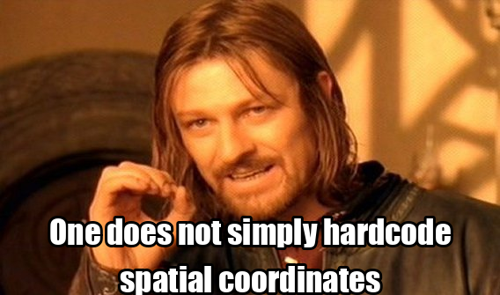

In [19]:
# --- 3. Run the Execution ---
# Call the function using the previously saved query and image bytes
final_meme = generate_smart_meme(winning_image_bytes, user_query)

print("\n--- Final SAM-Analyzed Meme ---")
final_meme.thumbnail((500, 500))
display(final_meme)